안정점 그리기

In [61]:
import numpy as np
import matplotlib.pyplot as plt

In [62]:
def Function(x, y):
    f_x_y = y

    g_x_y = x-x**2

    return(f_x_y, g_x_y)

In [63]:
def Eigen_Function(x, eigen_vector, z_f):
    for i in range(len(eigen_vector)):
        
        x_f = z_f[0][0]
        y_f = z_f[0][1]

        h = (eigen_vector[i][1]/eigen_vector[i][0])*(x-x_f)+y_f

        plt.plot(x, h, "--", color = "green", label = "eigen vector")

In [64]:
def Plot(
        x,
        y,
        f, 
        g,
        density = 1
        ):
    
    # plt.plot(x, f, color = "blue", label = r"$\dot{x}$")
    # plt.plot(x, g, color = "black", label = r"$\dot{y}$")

    X, Y = np.meshgrid(x, y)
    f, g = Function(X, Y)
    
    plt.contour(X, Y, f, levels = [0], color = "blue", label = r"$\dot{x}$")
    plt.contour(X, Y, g,levels = [0], color = "black", label = r"$\dot{y}$")

    U, V = Function(X, Y)

    # plt.quiver(X, Y, U, V, angles='xy')
    plt.streamplot(X, Y, U, V, density= density)

    plt.grid()
    plt.legend()

In [65]:
def Scatter(
        z_f,
        state
):
    
    for i in range(len(z_f)):
        x_f = z_f[i][0]
        y_f = z_f[i][1]

        if state[i] == "stable":
            color = "blue"

        elif state[i] == "saddle":
            color = "red"

        elif state[i] == "unstable":
            color = "orange"

        elif state[i] == "center":
            color = "black"

        else:
            print("Other state")

        plt.scatter(x_f, y_f, color = color, label = state[i])
        plt.legend(loc = "upper right")

/tmp/ipykernel_48573/2308094008.py:15: UserWarning: The following kwargs were not used by contour: 'color', 'label'
  plt.contour(X, Y, f, levels = [0], color = "blue", label = r"$\dot{x}$")
/tmp/ipykernel_48573/2308094008.py:16: UserWarning: The following kwargs were not used by contour: 'color', 'label'
  plt.contour(X, Y, g,levels = [0], color = "black", label = r"$\dot{y}$")
/tmp/ipykernel_48573/2308094008.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


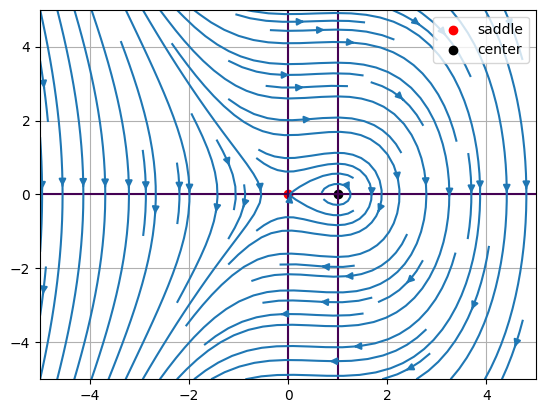

In [66]:
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)

f, g = Function(x, y)

Plot(x, y, f, g, density = 1)

# stable = blue, unstable = red, saddle = orange
z_f = [[0, 0], [1, 0]]
state = ["saddle", "center"]

Scatter(z_f, state)

# eigen_vector = [[1, (1+np.sqrt(5))/2], [1, (1-np.sqrt(5))/2]]

# Eigen_Function(x, eigen_vector, z_f)

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.show()

몬테카를로 방법

In [67]:
#라이브러리 출력
import numpy as np
import matplotlib.pyplot as plt

In [68]:
#총 개수와 파라미터 정의
N_total = 10000000

a = np.random.uniform(-1, 1, N_total)
b = np.random.uniform(-1, 1, N_total)
c = np.random.uniform(-1, 1, N_total)
d = np.random.uniform(-1, 1, N_total)

In [69]:
#판별식에서의 tau 와 Delta값 정의, 판별식 정의
tau = a+d
Delta = a*d-b*c
D = tau**2 -4*Delta

In [70]:
#안정점 계산 (참, 거짓)
saddle = Delta<0
stable_node = (tau<0)&(Delta>0)&(D>0)
unstable_node = (tau>0)&(Delta>0)&(D>0)
stable_spiral = (tau<0)&(Delta>0)&(D<0)
unstable_spiral = (tau>0)&(Delta>0)&(D<0)

In [71]:
#각 안정점의 갯수 평균
print("#"*30)
print(f"P(saddle) = {saddle.mean()}")
print(f"P(stable_node) = {stable_node.mean()}")
print(f"P(unstable_node) = {unstable_node.mean()}")
print(f"P(stable_spiral) = {stable_spiral.mean()}")
print(f"P(unstable_spiral) = {unstable_spiral.mean()}")
print("#"*30)

##############################
P(saddle) = 0.4999642
P(stable_node) = 0.0903451
P(unstable_node) = 0.0901392
P(stable_spiral) = 0.1596435
P(unstable_spiral) = 0.159908
##############################


In [72]:
tau_Point = []
Delta_Point = []

for i in [saddle, stable_node, unstable_node, stable_spiral, unstable_spiral]:
    tau_i = tau[i]
    Delta_i = Delta[i]

    tau_Point.append(tau_i)
    Delta_Point.append(Delta_i)

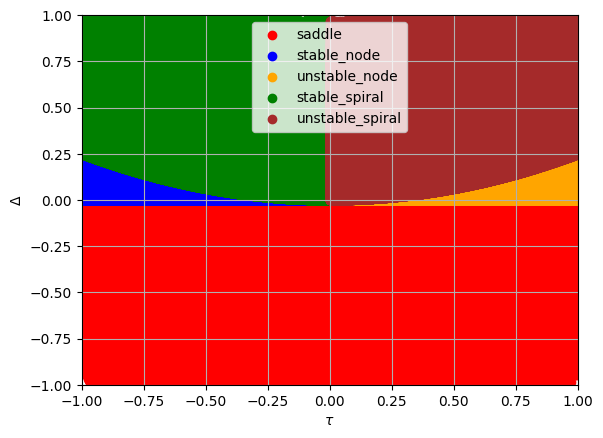

In [73]:
Point = ["saddle", "stable_node", "unstable_node", "stable_spiral", "unstable_spiral"]
color = ["red", "blue", "orange", "green", "brown"]

for i in range(len(tau_Point)):
    plt.scatter(tau_Point[i], Delta_Point[i], color = color[i], label = Point[i])

plt.xlim(-1, 1)
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\Delta$")
plt.ylim(-1, 1)
plt.legend()
plt.grid()
plt.show()